In [1]:
%load_ext autoreload
%autoreload 2

import sys
import random
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

from src.config import OUTPUTS, IMG_SIZE, SEED
from src.transfer import build_fine_tuner
from src.data import ImageDataset, get_transforms

torch.manual_seed(SEED)
random.seed(SEED)

LR_ADAPT       = 1e-5
EPOCHS         = 20
PATIENCE_ADAPT = 5

# Domain Adaptation - Fine-tuning sobre Imágenes de Redes Sociales

El modelo Transfer FT fue entrenado sobre paisajes, naturaleza y arte. Al recibir fotos de galería cotidianas (selfies, comida, eventos) falla porque nunca vio ese tipo de imágenes como "reales".

Este notebook hace un **fine-tuning incremental** sobre `ft_best.pt` usando el dataset **itw-sm** (In The Wild - Social Media): imágenes reales e IA generadas extraídas de Facebook, con contenido cotidiano similar al que subirían usuarios en el AI Fest.

Se usa un learning rate muy pequeño (1e-5) para evitar **catastrophic forgetting**, es decir que el modelo olvide lo que ya aprendió sobre el dominio original.

In [2]:
from datasets import disable_progress_bars
disable_progress_bars()

# Cargar dataset desde HuggingFace
print("Descargando itw-sm (puede tardar unos minutos la primera vez)...")
ds = load_dataset("dkarageo/itw-sm")
print(f"Splits disponibles: {list(ds.keys())}")

# Usar el split disponible (puede llamarse "test" o "train")
split_name = list(ds.keys())[0]
data = ds[split_name]
print(f"Usando split '{split_name}': {len(data)} imágenes")
print(f"Columnas: {data.column_names}")

# Separar por clase trabajando con ÍNDICES en lugar de materializar las imágenes.
# Las 10000 imágenes PIL no entran en RAM de esta máquina; se decodifican de forma
# lazy (memory-mapped Arrow) recién al accederlas en el DataLoader.
targets = data["target"]
real_items = [i for i, t in enumerate(targets) if t == 0]
fake_items = [i for i, t in enumerate(targets) if t == 1]
print(f"\nReal: {len(real_items)} | Fake: {len(fake_items)}")

# Usar todas las imágenes disponibles
random.shuffle(real_items)
random.shuffle(fake_items)

samples = [(idx, 0) for idx in real_items] + \
          [(idx, 1) for idx in fake_items]
labels  = [s[1] for s in samples]

print(f"Total a usar: {len(samples)} imágenes")

Descargando itw-sm (puede tardar unos minutos la primera vez)...


Splits disponibles: ['test']
Usando split 'test': 10000 imágenes
Columnas: ['image', 'label', 'target', 'platform']



Real: 5000 | Fake: 5000
Total a usar: 10000 imágenes


Train: 8001 | Val: 999 | Test itw-sm: 1000


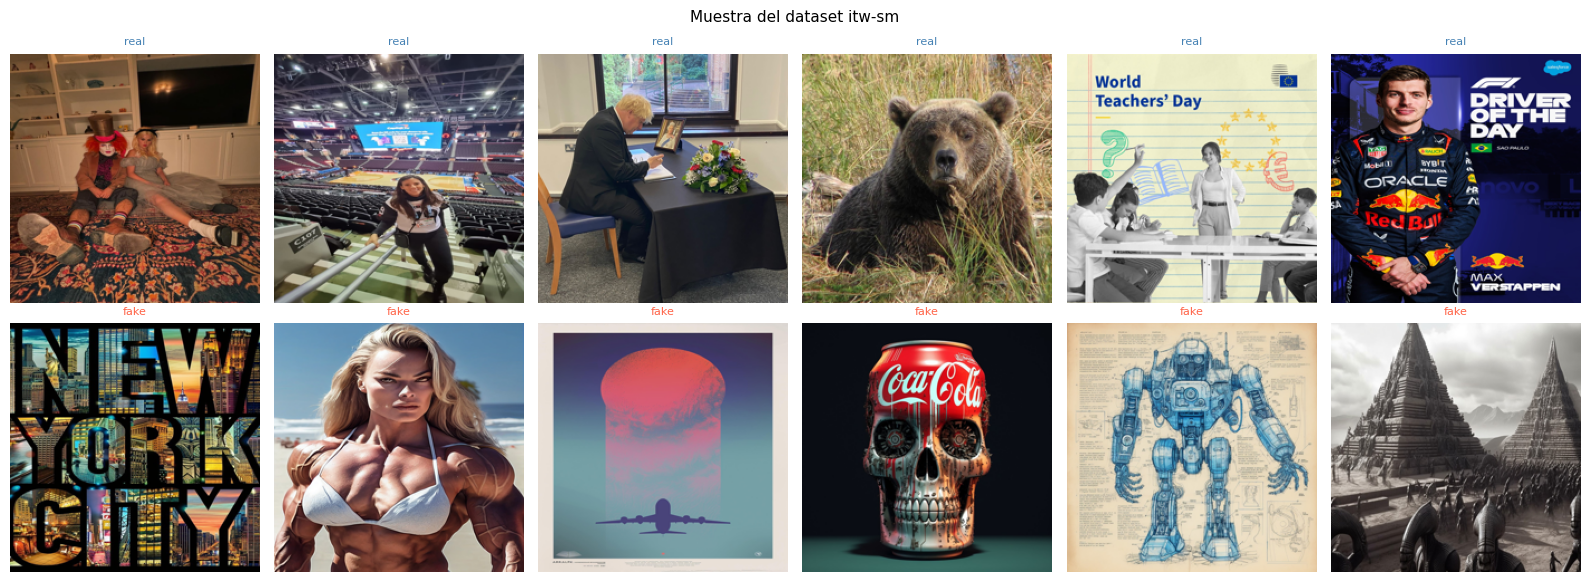

In [3]:
# Dataset que resuelve el índice a imagen PIL de forma lazy desde el dataset de
# HuggingFace (memory-mapped). Evita mantener las 10000 imágenes cargadas en RAM.
class PILDataset:
    def __init__(self, samples, transform):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        data_idx, label = self.samples[idx]
        img_pil = data[data_idx]["image"]
        img = img_pil.convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        return self.transform(img), label


# Split 80/10/10 estratificado: train / val / test-itw
train_val_s, test_itw_s = train_test_split(samples, test_size=0.10, stratify=labels, random_state=SEED)
labels_tv = [s[1] for s in train_val_s]
train_s, val_s = train_test_split(train_val_s, test_size=0.111, stratify=labels_tv, random_state=SEED)

print(f"Train: {len(train_s)} | Val: {len(val_s)} | Test itw-sm: {len(test_itw_s)}")

train_loader    = DataLoader(PILDataset(train_s,     get_transforms("train")), batch_size=32, shuffle=True)
val_loader      = DataLoader(PILDataset(val_s,       get_transforms("val")),   batch_size=32)
test_itw_loader = DataLoader(PILDataset(test_itw_s,  get_transforms("val")),   batch_size=32)

# Vista previa
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
real_imgs = [s for s in samples if s[1] == 0][:6]
fake_imgs = [s for s in samples if s[1] == 1][:6]

for col, (data_idx, _) in enumerate(real_imgs):
    axes[0, col].imshow(data[data_idx]["image"].convert("RGB").resize((IMG_SIZE, IMG_SIZE)))
    axes[0, col].set_title("real", fontsize=8, color="steelblue")
    axes[0, col].axis("off")

for col, (data_idx, _) in enumerate(fake_imgs):
    axes[1, col].imshow(data[data_idx]["image"].convert("RGB").resize((IMG_SIZE, IMG_SIZE)))
    axes[1, col].set_title("fake", fontsize=8, color="tomato")
    axes[1, col].axis("off")

plt.suptitle("Muestra del dataset itw-sm", fontsize=11)
plt.tight_layout()
plt.show()

## Fine-tuning incremental

Se carga `ft_best.pt` y se continúa entrenando con las imágenes nuevas. El learning rate es **1e-5** (100 veces menor que el fine-tuning original) para que el modelo ajuste sus pesos mínimamente, preservando lo aprendido sobre el dominio original.

Se descongelan `layer4` y `fc`, igual que en el fine-tuning original.

In [4]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

model = build_fine_tuner()
model.load_state_dict(torch.load(OUTPUTS / "ft_best.pt", map_location="cpu"))
model = model.to(device)
print("ft_best.pt cargado.")

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_ADAPT,
)

historial = {"train_loss": [], "val_loss": [], "val_acc": []}
mejor_val_loss = float("inf")
epochs_sin_mejora = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for imgs, lbs in train_loader:
        imgs = imgs.to(device)
        lbs  = lbs.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbs)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(imgs)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss, correct = 0.0, 0
    with torch.no_grad():
        for imgs, lbs in val_loader:
            imgs = imgs.to(device)
            lbs = lbs.float().unsqueeze(1).to(device)
            preds = model(imgs)
            val_loss += criterion(preds, lbs).item() * len(imgs)
            correct  += ((preds.sigmoid() >= 0.5) == lbs).sum().item()
    val_loss /= len(val_loader.dataset)
    val_acc = correct / len(val_loader.dataset)

    historial["train_loss"].append(train_loss)
    historial["val_loss"].append(val_loss)
    historial["val_acc"].append(val_acc)

    print(f"Epoch {epoch:3d}/{EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}", flush=True)

    if val_loss < mejor_val_loss:
        mejor_val_loss = val_loss
        epochs_sin_mejora = 0
        torch.save(model.state_dict(), OUTPUTS / "ft_adapted.pt")
    else:
        epochs_sin_mejora += 1
        if epochs_sin_mejora >= PATIENCE_ADAPT:
            print(f"Early stopping en epoch {epoch}.")
            break

print(f"\nMejor val_loss: {mejor_val_loss:.4f}")
print(f"Modelo guardado en outputs/ft_adapted.pt")

Dispositivo: cuda


ft_best.pt cargado.


Epoch   1/20  train_loss=0.4176  val_loss=0.3325  val_acc=0.8509


Epoch   2/20  train_loss=0.2657  val_loss=0.2511  val_acc=0.8909


Epoch   3/20  train_loss=0.2280  val_loss=0.2316  val_acc=0.9079


...

Epoch  17/20  train_loss=0.0484  val_loss=0.1755  val_acc=0.9439


Epoch  18/20  train_loss=0.0450  val_loss=0.1700  val_acc=0.9369


Epoch  19/20  train_loss=0.0389  val_loss=0.1700  val_acc=0.9359


Epoch  20/20  train_loss=0.0367  val_loss=0.1841  val_acc=0.9369



Mejor val_loss: 0.1700
Modelo guardado en outputs/ft_adapted.pt


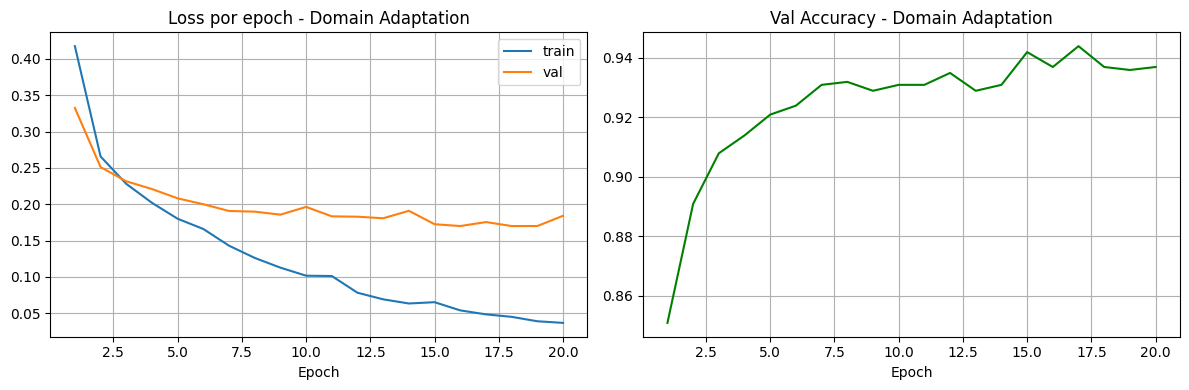

In [5]:
# Curvas de entrenamiento
epochs = range(1, len(historial["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, historial["train_loss"], label="train")
ax1.plot(epochs, historial["val_loss"], label="val")
ax1.set_title("Loss por epoch - Domain Adaptation")
ax1.set_xlabel("Epoch")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, historial["val_acc"], color="green")
ax2.set_title("Val Accuracy - Domain Adaptation")
ax2.set_xlabel("Epoch")
ax2.grid(True)

plt.tight_layout()
plt.show()

El modelo completó las 20 epochs sin que el early stopping frenara. La val_loss se estabilizó alrededro de 0.17 a partir del epoch 15, mientras que la train_loss siguió cayendo hasta 0.037, lo que podría ser señal de overfitting leve al final del entrenamiento. Sin embargo, la val_accuracy alcanzó un máximo de 94.4%, y el modelo guardado en `outputs/ft_adapted.pt` corresponde al mejor val_loss (epoch 16, val_acc = 93.7%).

## Evaluación: ¿el modelo olvidó lo que aprendió?

Se evalúa `ft_adapted.pt` sobre el **test set original** (paisajes, naturaleza, arte) y se comparan las métricas con el `ft_best.pt` original. Si el fine-tuning incremental funcionó bien, las métricas no deberían caer significativamente.

In [6]:
def evaluar(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            preds = (model(imgs).sigmoid() >= 0.5).int().squeeze().cpu()
            all_preds.append(preds)
            all_labels.append(labels)
    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_labels).numpy()
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    }


test_loader = DataLoader(ImageDataset("test"), batch_size=128, shuffle=False)

# Modelo original
model_orig = build_fine_tuner()
model_orig.load_state_dict(torch.load(OUTPUTS / "ft_best.pt", map_location="cpu"))
model_orig = model_orig.to(device)
metricas_orig = evaluar(model_orig, test_loader, device)

# Modelo adaptado
model_adapt = build_fine_tuner()
model_adapt.load_state_dict(torch.load(OUTPUTS / "ft_adapted.pt", map_location="cpu"))
model_adapt = model_adapt.to(device)
metricas_adapt = evaluar(model_adapt, test_loader, device)

print(f"{'Métrica':<12} {'ft_best.pt':>12} {'ft_adapted.pt':>14} {'Δ':>8}")
print("-" * 50)
for metrica in ["Accuracy", "Precision", "Recall", "F1"]:
    orig = metricas_orig[metrica]
    adapt = metricas_adapt[metrica]
    delta = adapt - orig
    signo = "+" if delta >= 0 else ""
    print(f"{metrica:<12} {orig:>12.4f} {adapt:>14.4f} {signo}{delta:>7.4f}")

Métrica        ft_best.pt  ft_adapted.pt        Δ
--------------------------------------------------
Accuracy           0.9373         0.8669 -0.0704
Precision          0.9365         0.8336 -0.1028
Recall             0.9383         0.9170 -0.0213
F1                 0.9374         0.8733 -0.0641


El modelo adaptado sufre una caída de 7% en accuracy sobre el dominio original (de 93.7% a 86.7%), lo que confirma la presencia de *catastrophic forgetting* (olvidar lo del dominio original). Sin embargo, la caída es chica y el modelo adaptado sigue funcionando bien en paisajes y arte, solo algo menos preciso. Este es el trade-off esperado al fine-tunear sobre datos de un dominio distinto sin incluir datos del dominio original en el entrenamiento.

## Evaluación: ¿mejoró en el dominio nuevo?

Se evalúa ambos modelos sobre el **test set de itw-sm** (imágenes de redes sociales reservadas, no vistas durante el fine-tuning). Esto mide si la adaptación realmente mejoró la capacidad del modelo para clasificar fotos cotidianas.

In [ ]:
metricas_orig_itw = evaluar(model_orig,  test_itw_loader, device)
metricas_adapt_itw = evaluar(model_adapt, test_itw_loader, device)

print(f"{'Métrica':<12} {'ft_best.pt':>12} {'ft_adapted.pt':>14} {'Δ':>8}")
print("-" * 50)
for metrica in ["Accuracy", "Precision", "Recall", "F1"]:
    orig = metricas_orig_itw[metrica]
    adapt = metricas_adapt_itw[metrica]
    delta = adapt - orig
    signo = "+" if delta >= 0 else ""
    print(f"{metrica:<12} {orig:>12.4f} {adapt:>14.4f} {signo}{delta:>7.4f}")

Métrica        ft_best.pt  ft_adapted.pt        Δ
--------------------------------------------------
Accuracy           0.6250         0.9450 + 0.3200
Precision          0.5736         0.9406 + 0.3670
Recall             0.9740         0.9500 -0.0240
F1                 0.7220         0.9453 + 0.2233


La adaptación al nuevo dominio fue muy buena. El modelo original (`ft_best.pt`) alcanzaba apenas un 62.5% de accuracy en imágenes de redes sociales, una performance muy cercana a algo random (50%) que lo hacía prácticamente inútil en este dominio. El modelo adaptado (`ft_adapted.pt`) sube a **94.5% de accuracy y 94.5% de F1** sobre el mismo conjunto, es decir una mejora del 32%. Esto confirma que el fine-tuning incremental con imágenes de redes sociales resolvió el problema de domain shift de forma contundente, haciendo al modelo apto para clasificar el tipo de fotos que subirían usuarios en el AI Fest.